# **Coleta de dados + Feature Engineering**

Carteira escolhida:

VALE3.SA → Vale

PETR4.SA → Petrobras

ITUB4.SA → Itaú Unibanco

/tmp/ipykernel_386/3611281440.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t,start='2019-01-01',end='2025-12-31')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_386/3611281440.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t,start='2019-01-01',end='2025-12-31')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_386/3611281440.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t,start='2019-01-01',end='2025-12-31')
[*********************100%***********************]  1 of 1 completed


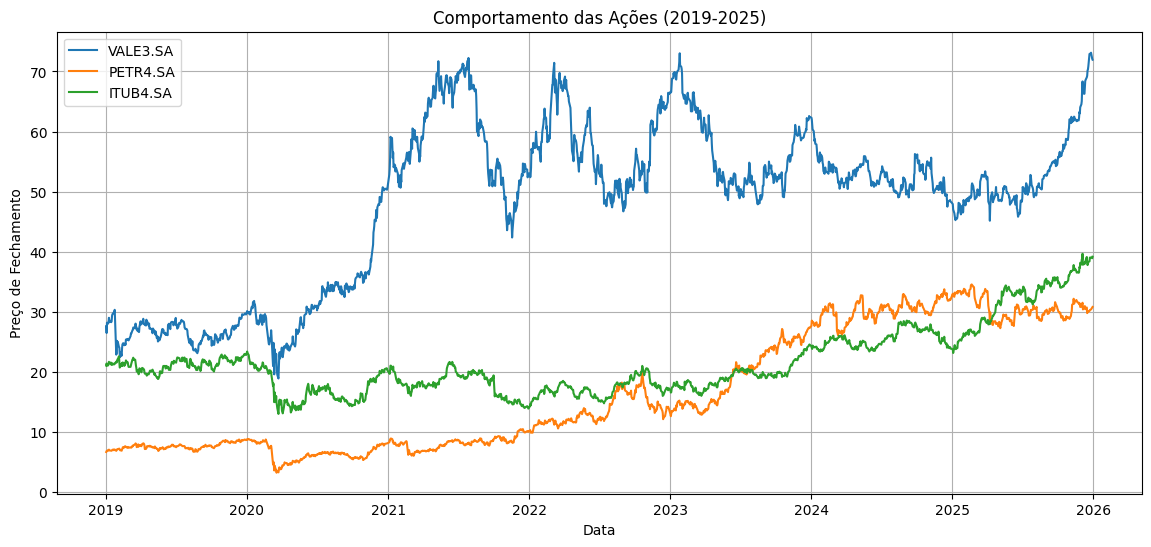

,VALE3.SA,PETR4.SA,ITUB4.SA
Date,,,
2019-01-02,27.611086,6.687146,21.073868
2019-01-03,26.481571,6.851129,21.421310
2019-01-04,28.205570,6.870584,21.062489
2019-01-07,28.054249,6.978981,21.102358
2019-01-08,28.324465,6.937288,21.370047


In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

tickers = ['VALE3.SA','PETR4.SA','ITUB4.SA']

dfs=[]

for t in tickers:

    df = yf.download(t,start='2019-01-01',end='2025-12-31')
    df = df[['Close']]
    df.columns=[t]

    dfs.append(df)

data = pd.concat(dfs,axis=1).dropna()

# gráfico
plt.figure(figsize=(14,6))

for col in data.columns:
    plt.plot(data.index, data[col], label=col)

plt.title('Comportamento das Ações (2019-2025)')
plt.xlabel('Data')
plt.ylabel('Preço de Fechamento')
plt.legend()
plt.grid()

plt.show()


data.head()


# **Pipeline geral antes da LSTM**

 calcular o n passos, de quanto tempo em quanto tempo a acao sobe.

In [ ]:
# exemplo com VALE3
serie = data['VALE3.SA']

# variação diária
diff = serie.diff()

# dias em que o preço subiu
up = diff > 0

# índices dos dias de subida
up_idx = np.where(up)[0]

# distância entre subidas
n_steps = np.diff(up_idx)

print("Passos entre subidas:", n_steps[:20])
print("Média de passos:", np.mean(n_steps))

Passos entre subidas: [2 1 3 2 1 1 1 2 1 2 1 2 5 2 1 1 1 2 1 2]
Média de passos: 2.01508120649652


dados nas escalas 0 a 1 ou -1 a 1,

In [ ]:
# --- CHECAR SE OS VALORES ESTÃO NA FAIXA -1 A 1 ---

# df_scaled contém as features T1-T4 e target normalizados
print("Valores mínimos por coluna:")
print(df_scaled.min())

print("\nValores máximos por coluna:")
print(df_scaled.max())

# opcional: ver o dataset normalizado
print("\nPrimeiras linhas do dataset normalizado (-1 a 1):")
print(df_scaled.head())

Valores mínimos por coluna:
t1       -1.0
t2       -1.0
t3       -1.0
t4       -1.0
target   -1.0
dtype: float64

Valores máximos por coluna:
t1        1.0
t2        1.0
t3        1.0
t4        1.0
target    1.0
dtype: float64

Primeiras linhas do dataset normalizado (-1 a 1):
         t1        t2        t3        t4    target
0 -0.705878 -0.698258 -0.684570 -0.696882 -0.700372
1 -0.698258 -0.684570 -0.696882 -0.693178 -0.667711
2 -0.684570 -0.696882 -0.693178 -0.659733 -0.656756
3 -0.696882 -0.693178 -0.659733 -0.648515 -0.648074
4 -0.693178 -0.659733 -0.648515 -0.639624 -0.638358


Separar treino (2019-2024) e teste (2025)

In [ ]:
train = data.loc['2019':'2024']
test  = data.loc['2025']

In [ ]:
#features temporais (t1, t2, t3, t4)
def create_features(series, n_features=4):

    df = pd.DataFrame()

    for i in range(1, n_features+1):
        df[f't{i}'] = series.shift(i)

    df['target'] = series

    return df.dropna()

T’s (t1, t2, t3, t4) como segmentos definidos por n_steps (periodo entre mudancas significativas no stock)

In [ ]:
features = create_features(data['VALE3.SA'],4)

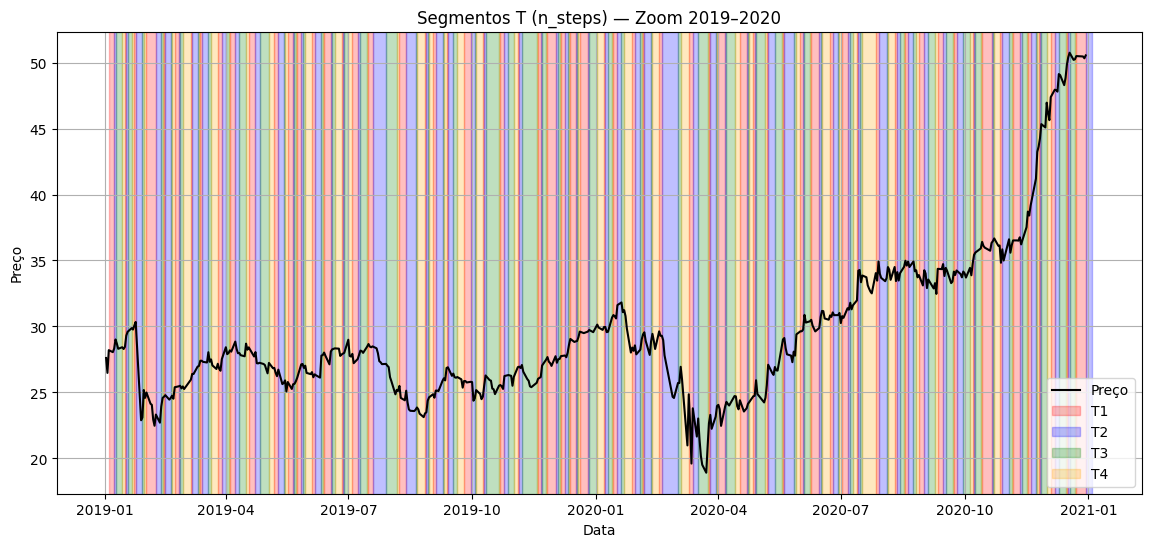

In [ ]:
# --- ZOOM 2019-2020 COM HIGHLIGHT DOS SEGMENTOS ---

import matplotlib.pyplot as plt

# filtrar período
serie_zoom = serie.loc['2019':'2020']

plt.figure(figsize=(14,6))
plt.plot(serie_zoom.index, serie_zoom.values, label="Preço", color="black")

colors = ["red","blue","green","orange"]

start = up_idx[0]
t_counter = 0

for step in n_steps:

    end = start + step

    if end >= len(serie):
        break

    start_date = serie.index[start]
    end_date = serie.index[end]

    # só desenhar se estiver no período 2019-2020
    if start_date >= serie_zoom.index[0] and start_date <= serie_zoom.index[-1]:

        plt.axvspan(
            start_date,
            end_date,
            color=colors[t_counter % 4],
            alpha=0.25,
            label=f"T{(t_counter % 4)+1}" if t_counter < 4 else None
        )

    start = end
    t_counter += 1

plt.title("Segmentos T (n_steps) — Zoom 2019–2020")
plt.xlabel("Data")
plt.ylabel("Preço")
plt.legend()
plt.grid()

plt.show()

thresholds na faixa -1 a 1

In [ ]:
# --- criar features ---
features = create_features(data['VALE3.SA'], n_features=4)

# --- separar treino e teste ---
train_features = features.loc['2019':'2024']
test_features  = features.loc['2025']

# --- separar X e y ---
X_train = train_features[['t1','t2','t3','t4']].values
y_train = train_features['target'].values

X_test  = test_features[['t1','t2','t3','t4']].values
y_test  = test_features['target'].values

# verificar shapes
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (1488, 4) y_train: (1488,)
X_test: (250, 4) y_test: (250,)


# **treinando a rede neural.**
Número de camadas	2	= 1 camada LSTM + 1 camada Dense
Número de unidades (neurônios) na LSTM	50	Cada unidade aprende uma característica temporal da sequência
Camada de saída	1 (Dense, tanh)	Produz o valor contínuo normalizado entre -1 e 1

In [ ]:
!pip install yfinance matplotlib scikit-learn torch --quiet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# --- FUNÇÃO PARA CRIAR FEATURES T1-T4 ---
def create_features(series, n_features=4):
    df = pd.DataFrame()
    for i in range(1, n_features+1):
        df[f't{i}'] = series.shift(i)
    df['target'] = series
    return df.dropna()

# --- CRIAR FEATURES ---
features = create_features(data['VALE3.SA'], n_features=4)

# --- SEPARAR TREINO E TESTE ---
train_features = features.loc['2019':'2024']
test_features  = features.loc['2025']

# --- SEPARAR X E Y ---
X_train = train_features[['t1','t2','t3','t4']].values
y_train = train_features['target'].values
X_test  = test_features[['t1','t2','t3','t4']].values
y_test  = test_features['target'].values

# --- NORMALIZAR PARA -1 A 1 ---
scaler_X = MinMaxScaler(feature_range=(-1,1))
scaler_y = MinMaxScaler(feature_range=(-1,1))

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1,1))
y_test_scaled  = scaler_y.transform(y_test.reshape(-1,1))

# --- RESHAPE PARA LSTM ---
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_lstm  = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

# --- CRIAR MODELO LSTM ---
model = Sequential()
model.add(LSTM(50, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
model.add(Dense(1, activation='tanh'))  # tanh mantém saída entre -1 e 1
model.compile(optimizer='adam', loss='mse')

# --- TREINAR ---
history = model.fit(
    X_train_lstm, y_train_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# --- PREVISÃO ---
y_pred_scaled = model.predict(X_test_lstm)

# --- APLICAR THRESHOLDS PARA LONG / SHORT MEMORY ---
threshold_high = 0.5
threshold_low  = -0.5

y_pred_class = np.where(y_pred_scaled >= threshold_high, 1,
                        np.where(y_pred_scaled <= threshold_low, -1, 0))

# --- RESULTADOS ---
print("Primeiras previsões contínuas (LSTM):")
print(y_pred_scaled[:10].flatten())
print("\nPrimeiras classes (Long/Short Memory):")
print(y_pred_class[:10].flatten())

KeyError: 'VALE3.SA'

Definição da Rede Neural

Aqui ficam claros L e n.

L	Long Memory	≥ 0.5
S	Short Memory	≤ -0.5
N	Neutro	entre -0.5 e 0.5

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# --- FUNÇÃO PARA CRIAR FEATURES T1-T4 ---
def create_features(series, n_features=4):
    df = pd.DataFrame()
    for i in range(1, n_features+1):
        df[f't{i}'] = series.shift(i)
    df['target'] = series
    return df.dropna()

# --- CRIAR FEATURES ---
features = create_features(data['VALE3.SA'], n_features=4)

# --- SEPARAR TREINO E TESTE ---
train_features = features.loc['2019':'2024']
test_features  = features.loc['2025']

# --- SEPARAR X E Y ---
X_train = train_features[['t1','t2','t3','t4']].values
y_train = train_features['target'].values
X_test  = test_features[['t1','t2','t3','t4']].values
y_test  = test_features['target'].values

# --- NORMALIZAR PARA -1 A 1 ---
scaler_X = MinMaxScaler(feature_range=(-1,1))
scaler_y = MinMaxScaler(feature_range=(-1,1))

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1,1))
y_test_scaled  = scaler_y.transform(y_test.reshape(-1,1))

# --- RESHAPE PARA LSTM ---
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_lstm  = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

# --- CRIAR MODELO LSTM ---
model = Sequential()
model.add(LSTM(50, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
model.add(Dense(1, activation='tanh'))  # saída entre -1 e 1
model.compile(optimizer='adam', loss='mse')

# --- TREINAR ---
history = model.fit(
    X_train_lstm, y_train_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# --- PREVISÃO ---
y_pred_scaled = model.predict(X_test_lstm)

# --- APLICAR THRESHOLDS PARA LONG / SHORT MEMORY ---
threshold_high = 0.5
threshold_low  = -0.5

# criar labels claras
y_pred_labels = np.where(
    y_pred_scaled >= threshold_high, 'L',
    np.where(y_pred_scaled <= threshold_low, 'S', 'N')
)

# --- RESULTADOS ---
print("Primeiras previsões contínuas (LSTM):")
print(y_pred_scaled[:10].flatten())
print("\nPrimeiras classes (L=Long, S=Short, N=Neutro):")
print(y_pred_labels[:10].flatten())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.1582 - val_loss: 0.0016
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0062 - val_loss: 0.0028
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0041 - val_loss: 0.0017
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0040 - val_loss: 0.0019
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0040 - val_loss: 0.0020
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0039 - val_loss: 0.0016
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0039 - val_loss: 0.0025
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0039 - val_loss: 0.0018
Epoch 9/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0038 - val_loss: 0.0015
Epoch 10/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0038 - val_loss: 0.0016
Epoch 11/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0037 - val_loss: 0.0017
Epoch 12/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0036 - val_

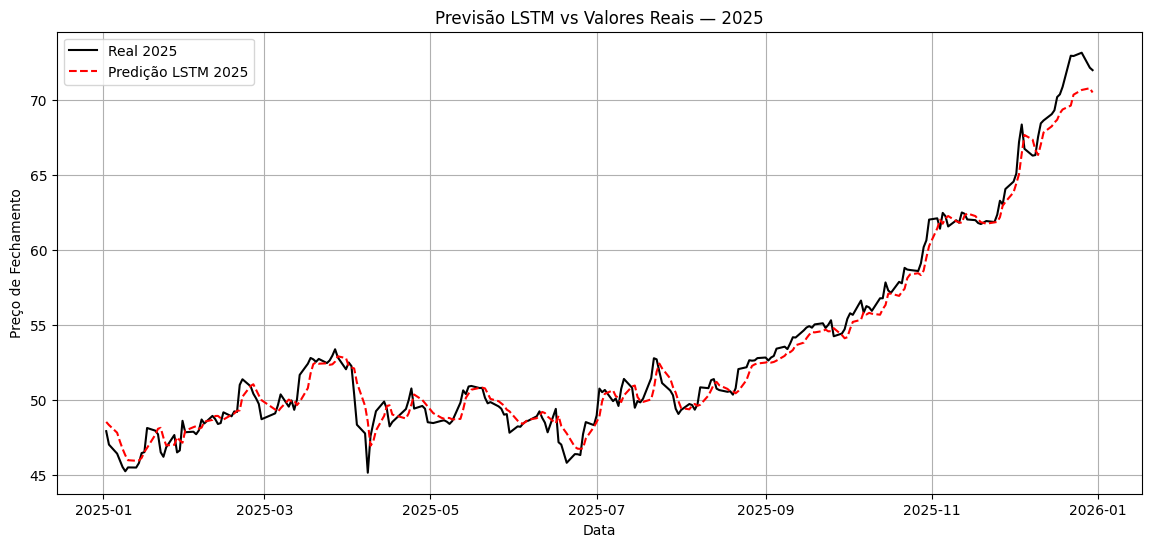

In [ ]:
import matplotlib.pyplot as plt

# --- DESNORMALIZAR PARA ESCALA ORIGINAL ---
y_pred_orig = scaler_y.inverse_transform(y_pred_scaled)
y_test_orig = scaler_y.inverse_transform(y_test_scaled)

# --- GRÁFICO COMPARATIVO ---
plt.figure(figsize=(14,6))
plt.plot(test_features.index, y_test_orig, label="Real 2025", color="black")
plt.plot(test_features.index, y_pred_orig, label="Predição LSTM 2025", color="red", linestyle="--")
plt.title("Previsão LSTM vs Valores Reais — 2025")
plt.xlabel("Data")
plt.ylabel("Preço de Fechamento")
plt.legend()
plt.grid()
plt.show()

valores reais de 2025 e sobrepor os segmentos classificados como L (Long Memory), S (Short Memory) e N (Neutro)

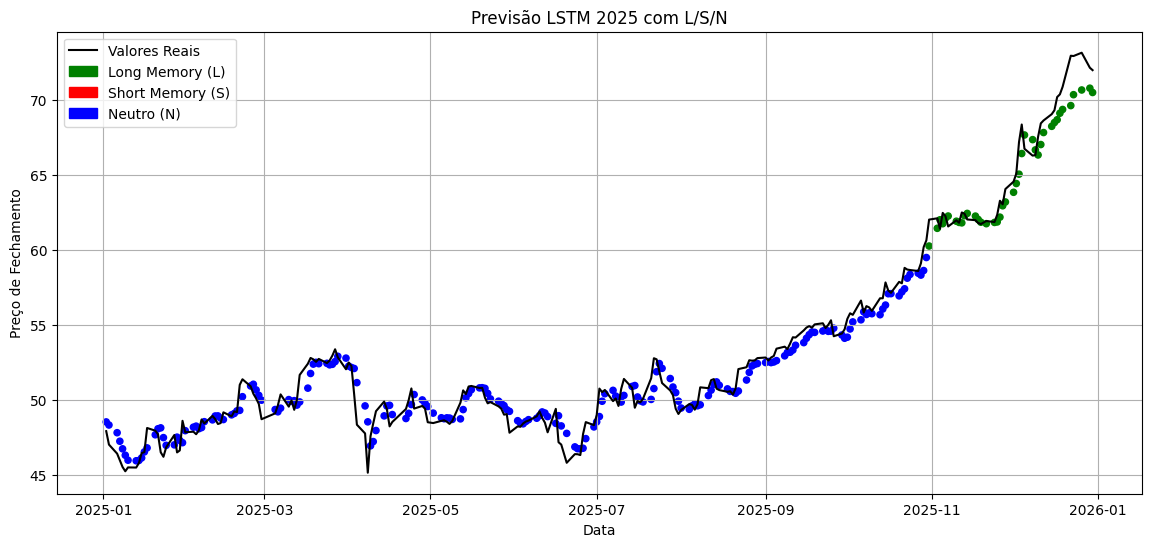

In [ ]:
import matplotlib.pyplot as plt

# cores
colors = {'L':'green', 'S':'red', 'N':'blue'}
segment_colors = [colors[label] for label in y_pred_labels.flatten()]

plt.figure(figsize=(14,6))
plt.plot(test_features.index, y_test_orig, label="Valores Reais", color="black")

# sobrepor as classes como scatter plot colorido
plt.scatter(test_features.index, y_pred_orig, c=segment_colors, s=20)

# legenda customizada
import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color='green', label='Long Memory (L)'),
                  mpatches.Patch(color='red', label='Short Memory (S)'),
                  mpatches.Patch(color='blue', label='Neutro (N)')]
plt.legend(handles=[plt.Line2D([], [], color='black', label='Valores Reais')] + legend_patches)

plt.title("Previsão LSTM 2025 com L/S/N")
plt.xlabel("Data")
plt.ylabel("Preço de Fechamento")
plt.grid()
plt.show()

<bound method NDFrame.describe of              VALE3.SA   PETR4.SA   ITUB4.SA
Date                                       
2019-01-02  27.611086   6.687146  21.073868
2019-01-03  26.481571   6.851129  21.421310
2019-01-04  28.205570   6.870584  21.062489
2019-01-07  28.054249   6.978981  21.102358
2019-01-08  28.324465   6.937288  21.370047
...               ...        ...        ...
2025-12-22  72.919998  30.147873  38.408195
2025-12-23  72.900002  30.309999  39.038471
2025-12-26  73.120003  30.410000  39.051075
2025-12-29  72.120003  30.730000  38.931229
2025-12-30  71.959999  30.820000  39.180916

[1742 rows x 3 columns]>